# 8. Quantum Teleportation

One of the coolest applications of entanglement is the **teleportation** of quantum states from one quantum object (e.g., a photon) to another. The basic principle relies on transferring the state of one qubit to another using a third and fourth qubit that form an entangled resource pair. Below is an illustration of the experimental setup

<img src="images/teleportation.png" width="900">

In this notebook, you will learn about the exact functioning of the protocol visually and implement it yourself. You can try it with these challenges first, and then read and understand the theory, or do a mix of both.

In [1]:
from qc_interactive_education_package import ChallengeViewer
import numpy as np

# Step 1: Create Bell state between qubits 2 and 3
viewer = ChallengeViewer(
    num_qubits=3,
    initial_state=[np.sqrt(2)/np.sqrt(3), np.exp(1j*-np.pi/4)/np.sqrt(3),0,0,0,0,0,0],
    target_state=[np.sqrt(2)/np.sqrt(3), np.exp(1j*-np.pi/4)/np.sqrt(3),0,0,0,0,np.sqrt(2)/np.sqrt(3), np.exp(1j*-np.pi/4)/np.sqrt(3)]
)

viewer.display()

# Step 2: Entangle qubits 1 and 2
viewer_2 = ChallengeViewer(
    num_qubits=3,
    initial_state=[np.sqrt(2)/np.sqrt(3), np.exp(1j*-np.pi/4)/np.sqrt(3),0,0,0,0,np.sqrt(2)/np.sqrt(3), np.exp(1j*-np.pi/4)/np.sqrt(3)],
    target_state=[np.sqrt(2)/np.sqrt(3), np.sqrt(2)/np.sqrt(3),np.exp(1j*-np.pi/4)/np.sqrt(3),np.exp(3j*np.pi/4)/np.sqrt(3),np.exp(1j*-np.pi/4)/np.sqrt(3),np.exp(3j*np.pi/4)/np.sqrt(3),np.sqrt(2)/np.sqrt(3), np.sqrt(2)/np.sqrt(3)]
)

viewer_2.display()


Now measure and readout the state. Copy paste it as the target state below to complete the challenge.

In [5]:
from qc_interactive_education_package import ChallengeViewer
import numpy as np

# Step 3:
viewer_3 = ChallengeViewer(
    num_qubits=1,
    initial_state=[1,1], # TODO: Your initial state from the measurement here
    target_state= [np.sqrt(2)/np.sqrt(3), np.exp(1j*-np.pi/4)/np.sqrt(3)]
)

viewer_3.display()

## 8.1. The Theory of Teleportation

To understand why the circuit works, we have to look at the quantum states mathematically.

Suppose Alice wants to teleport a qubit state $|\psi\rangle_1 = \alpha|0\rangle + \beta|1\rangle$ to Bob. They cannot just copy it (No-Cloning Theorem). Instead, they share an entangled resource, a Bell pair $|\Phi^+\rangle_{2,3}$ (where qubit 2 is Alice's and qubit 3 is Bob's).

The total state of the three qubits (1, 2, 3) starts as:
$$|\Psi\rangle_{total} = |\psi\rangle_1 \otimes |\Phi^+\rangle_{2,3} = (\alpha|0\rangle_1 + \beta|1\rangle_1) \otimes \frac{1}{\sqrt{2}}(|00\rangle_{2,3} + |11\rangle_{2,3})$$

Note that, at this point, we call the state partially entangled, because the subsystem of qubits 2 and 3 are entangled, while that subsystem is independent of qubit 1.

If we expand this, we get a mix of all three qubits. However, the "magic" happens if we rewrite Alice's two qubits (1 and 2) in the **Bell Basis** ($|\Phi^\pm\rangle, |\Psi^\pm\rangle$). By doing some algebra, we can rewrite the total state as:

$$|\Psi\rangle_{total} = \frac{1}{2} [ |\Phi^+\rangle_{1,2} \otimes (\alpha|0\rangle + \beta|1\rangle)_2 + |\Phi^-\rangle_{1,2} \otimes (\alpha|0\rangle - \beta|1\rangle)_3 + |\Psi^+\rangle_{1,2} \otimes (\beta|0\rangle + \alpha|1\rangle)_3 + |\Psi^-\rangle_{1,2} \otimes (-\beta|0\rangle + \alpha|1\rangle)_3 ]$$

**What does this tell us?**
It implies that Bob's qubit (qubit 3) is *already* in a state that looks very similar to Alice's original $|\psi\rangle_1$, but it depends on what state Alice's qubits are in.

We can also describe this visually in DCN. Notice how the information from qubit 1 (green, here $|\psi\rangle_1=\frac{\sqrt{2}}{\sqrt{3}}|0\rangle+\frac{1}{\sqrt{3}}e^{-i\pi/4}|1\rangle$) is transferred to qubit 3 (orange) using only operations on qubit 1 and 2 (Hadamard and CNOT).

<img src="images/teleportation_main.png" width="900">

1.  **Alice Measures:** Alice performs a "Bell Measurement" on qubits 1 and 2. This collapses the superposition into one of the four Bell states.
2.  **Bob's State Collapses:** Immediately upon Alice's measurement, Bob's qubit collapses into the corresponding state from the equation above.
3.  **Correction:** Alice sends her measurement result (2 classical bits) to Bob. Bob applies a gate to "fix" his state back to $\alpha|0\rangle + \beta|1\rangle$.

| Alice Measures | Bob's State | Correction Gate Needed |
| :--- | :--- | :--- |
| $|\Phi^+\rangle$ (00) | $\alpha|0\rangle + \beta|1\rangle$ | Identity ($I$) |
| $|\Phi^-\rangle$ (01) | $\alpha|0\rangle - \beta|1\rangle$ |  |
| $|\Psi^+\rangle$ (10) | $\beta|0\rangle + \alpha|1\rangle$ |  |
| $|\Psi^-\rangle$ (11) | $-\beta|0\rangle + \alpha|1\rangle$ |  |

Visually, the measurement can be described like so:

<img src="images/teleportation_measurement.png" width="900">

These figures are adapted from [1].

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
Your Task: Which unitary operations does Bob need to apply in order to get qubit 3 into the original state of qubit 1? Keep in mind that a measurement would collapse the state! Fill out the table above.
</div>

## 8.2. Implementation

Let's implement this!

State to teleport:


<IPython.core.display.Latex object>

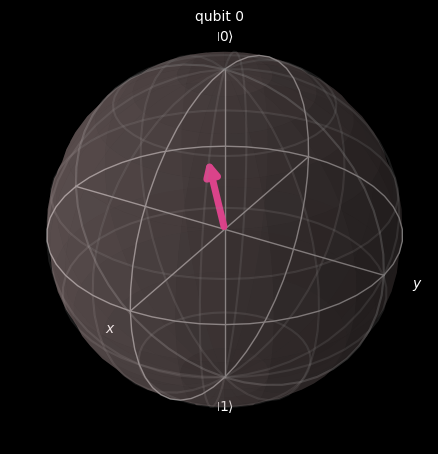

In [2]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_bloch_multivector, array_to_latex
from qiskit.quantum_info import random_statevector, Statevector
import numpy as np

# Import our custom visualization tool
from qc_interactive_education_package import DimensionalCircleNotation

# Generate a random state to teleport
psi = random_statevector(2)

# Remove global phase: rotate so the global phase is 0 (first element becomes real). This doesnt change the physics.
psi = Statevector(np.exp(-1j * np.angle(psi.data[0])) * psi.data)

print("State to teleport:")
display(array_to_latex(psi, prefix="|\\psi\\rangle_{initial} ="))
display(plot_bloch_multivector(psi))
plt.close()

### Step 1: The Protocol Setup

We need 3 Qubits and 2 Classical Bits.
* **Q1:** The qubit Alice wants to send (initialized in state $|\psi\rangle$).
* **Q2:** Alice's half of the entangled pair.
* **Q3:** Bob's half of the entangled pair.

**Task:** Initialize the circuit. Set Q1 to the state `psi` (using `initialize`) and create a Bell pair ($|\Phi^+\rangle$) between Q2 and Q3.

System State after Bell state creation (DCN Visualization):


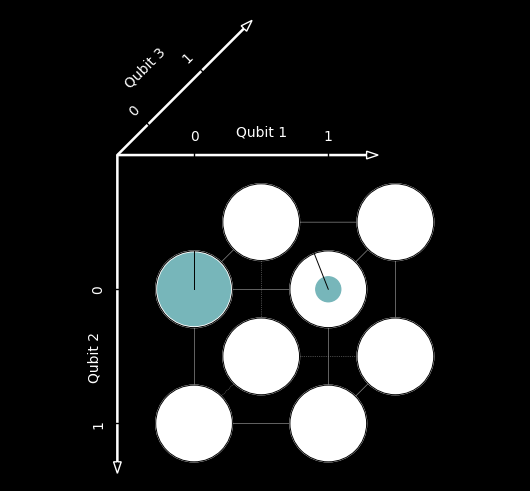

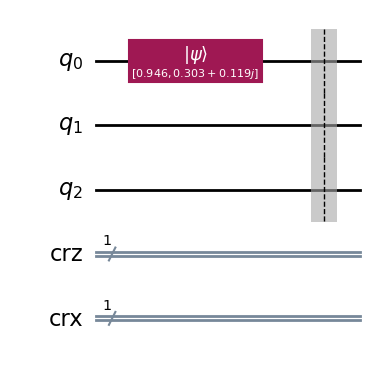

In [3]:
# Setup Registers
qr = QuantumRegister(3, name="q")
crz, crx = ClassicalRegister(1, name="crz"), ClassicalRegister(1, name="crx")
teleportation_circuit = QuantumCircuit(qr, crz, crx)

# STEP 0: Initialize q1 in state psi
# Note: In a real experiment, we can't just "plug in" a state vector,
# but for simulation, we can prepare q1 in this specific random state.
# q1 has index 0 in our program!
teleportation_circuit.initialize(psi.data, 0)

# STEP 1: Create a Bell pair between q1 and q2 (Shared Resource)
# Apply H to q1 and CX between q1 and q2
# --- Your Code Here ---


# ----------------------

print("System State after Bell state creation (DCN Visualization):")
DimensionalCircleNotation.from_qiskit(teleportation_circuit).show()

teleportation_circuit.barrier() # Visual separation
display(teleportation_circuit.draw(output="mpl"))
plt.close()

### Step 2: Bell Measurement Preparation

Alice now needs to measure her two qubits (Q1 and Q2) in the **Bell Basis**. Standard quantum computers only measure in the Z-basis ($|0\rangle, |1\rangle$). To measure in the Bell basis, we have to "rotate" the Bell states into the Z-basis states ($|00\rangle, |01\rangle, \dots$).

This is done by reversing the circuit that creates Bell states:
1.  Apply a **CNOT** gate between Q1 and Q2.
2.  Apply a **Hadamard** gate to Q1.

**Task:** Implement these gates for Alice. Afterward, we will visualize the full system state before measurement to see the entanglement structure.

System State before Measurement (DCN Visualization):


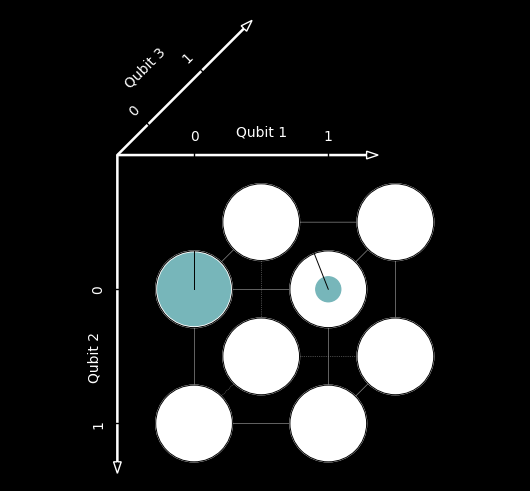

In [4]:
# STEP 2: Alice maps her qubits to the Bell Basis
# Apply CX(0, 1) and H(0)
# --- Your Code Here ---


# ----------------------


# Visualize using DCN (Dimensional Circle Notation) to see correlations
print("System State before Measurement (DCN Visualization):")
DimensionalCircleNotation.from_qiskit(teleportation_circuit).show()

### Step 3 & 4: Measurement and Correction

Now Alice measures her qubits and sends the results to Bob.
* Measure Q1 into the classical register `crz`.
* Measure Q2 into the classical register `crx`.

Based on these results, Bob must apply gates to Q2 to recover the original state $|\psi\rangle$.
* If `crx` is 1 (corresponds to measurement results mapping to $\Psi^+$ or $\Phi^-$ term contributions related to X), Bob applies **X**.
* If `crz` is 1, Bob applies **Z**.

**Task:** Add the measurements and the conditional gates (dynamic circuits).

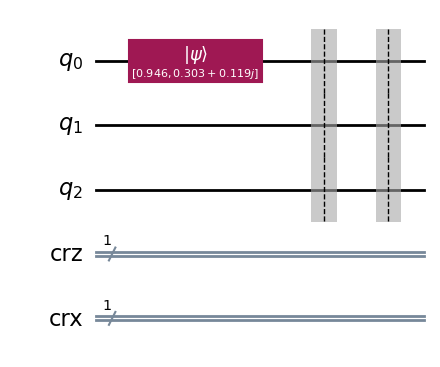

In [5]:
teleportation_circuit.barrier()

# STEP 3: Alice measures her qubits
# Measure q1 -> crz
# Measure q2 -> crx
# --- Your Code Here ---


# ----------------------

# STEP 4: Bob applies correction gates based on classical bits

with teleportation_circuit.if_test((crx, 1)):
    # --- Your Code Here (Apply X to q3 (index 2)) ---
    pass

with teleportation_circuit.if_test((crz, 1)):
    # --- Your Code Here (Apply Z to q3 (index 2)) ---
    pass

# Draw the circuit
teleportation_circuit.draw(output="mpl")

### Verification

If the protocol worked, the state of Qubit 2 (Bob's qubit) should now be identical to the initial random state $|\psi\rangle$ we created at the start. Note that Qubit 1 and 2 have collapsed and are no longer in that state.

Let's simulate the circuit and check the final state vector of Qubit 3.

Final System State:


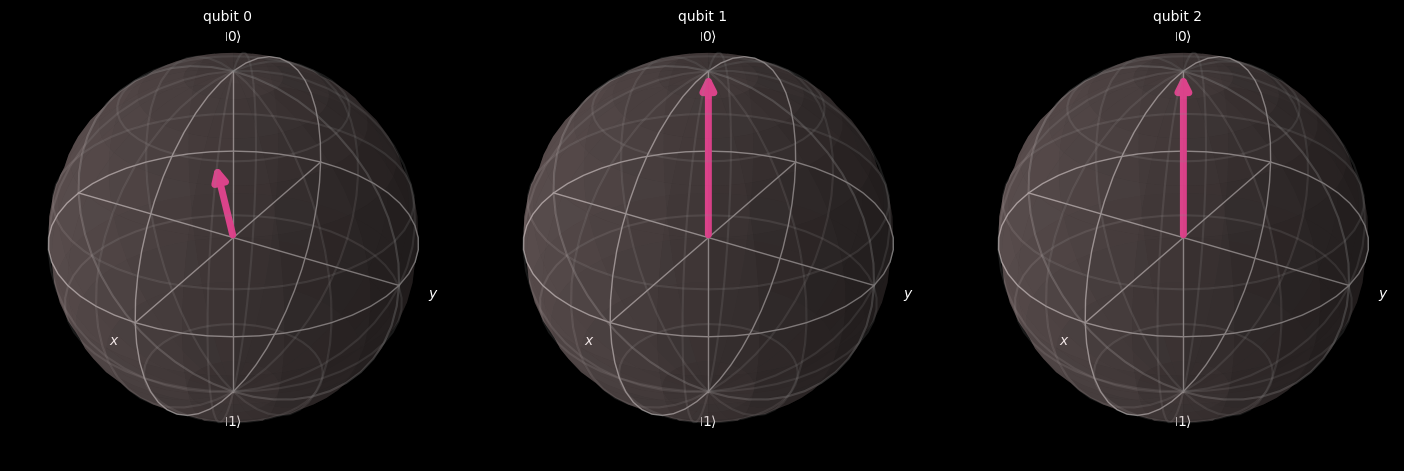

Original State for Comparison:


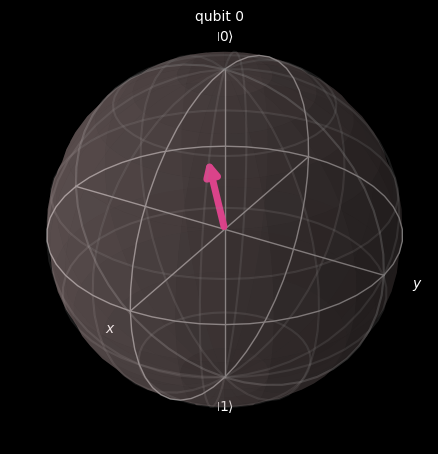

Teleportation Fidelity: 0.894192
FAILURE: The states do not match.


In [6]:
# Save final state
teleportation_circuit.save_statevector()

# Run Simulation
sim_backend = Aer.get_backend('aer_simulator')
result = sim_backend.run(teleportation_circuit).result()
final_state = result.get_statevector()

# Verify by plotting
# We plot the Bloch vector for all qubits.
# Q1 and Q2 will be 0 or 1 (collapsed), Q3 should match our original psi.
print("Final System State:")
display(plot_bloch_multivector(final_state))

print("Original State for Comparison:")
display(plot_bloch_multivector(psi))
plt.close('all')

from qiskit.quantum_info import partial_trace, state_fidelity

# 1. Extract the state of the target qubit (Qubit 3)
# We trace out the measured qubits (Qubit 1 and 2) to isolate Bob's qubit.
# Note: partial_trace takes the state and the list of indices to REMOVE.
bob_state = partial_trace(final_state, [0, 1])

# 2. Calculate Fidelity
# Fidelity F = |<psi|bob_state>|^2. A value of 1.0 means perfect identity.
fidelity = state_fidelity(psi, bob_state)

print(f"Teleportation Fidelity: {fidelity:.6f}")

if fidelity > 0.9999:
    print("SUCCESS: The state has been perfectly teleported!")
else:
    print("FAILURE: The states do not match.")

# 8.3. Conclusion: The Reality of Teleportation

In this notebook, we have implemented one of the most fascinating protocols in quantum mechanics: **Quantum Teleportation**.

We have demonstrated that it is possible to transfer an unknown quantum state $|\psi\rangle$ from Alice to Bob, even if they are physically separated, by using a shared **entangled pair** as a resource. This process highlights a fundamental feature of quantum mechanics: operations performed on a local subsystem (Alice's Bell measurement) instantaneously change the global state of the entire system, effectively "steering" Bob's qubit into a state related to $|\psi\rangle$.

### Key Takeaways

1.  **Not Faster Than Light:** While the quantum state collapse is instantaneous, the protocol is **not** faster than the speed of light. Bob cannot reconstruct the state until he receives two bits of **classical information** from Alice. Without these bits, his qubit remains a random mixture.
2.  **Information, not Matter:** Teleportation transfers **quantum information** (the amplitudes $\alpha$ and $\beta$), not physical matter. The original qubit is destroyed (measured) in the process, preventing cloning.
3.  **Future Applications:** Quantum teleportation is the foundation of the future **Quantum Internet**.

It will be used to:

* Connect distant quantum computers into a single network.
* Distribute entanglement for secure communication (Quantum Key Distribution).
* Transfer states between different parts of a modular quantum processor.

## References

[1] Bley, J., Rexigel, E., Arias, A., Longen, N., Krupp, L., Kiefer-Emmanouilidis, M., Lukowicz, P., Donhauser, A., Küchemann, S., Kuhn, J., & Widera, A. (2024). Visualizing entanglement in multiqubit systems. Physical Review Research, **6**(2), 023077.